<a href="https://colab.research.google.com/github/brina-malaquias/Inteligencia-Artificial---A1/blob/main/A1_IA_Sabrina_Malaquias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Época 0, Erro: 0.2676
Saídas finais:
Entrada: [0 0], Saída Prevista: [1.]
Entrada: [0 1], Saída Prevista: [1.]
Entrada: [1 0], Saída Prevista: [0.]
Entrada: [1 1], Saída Prevista: [1.]


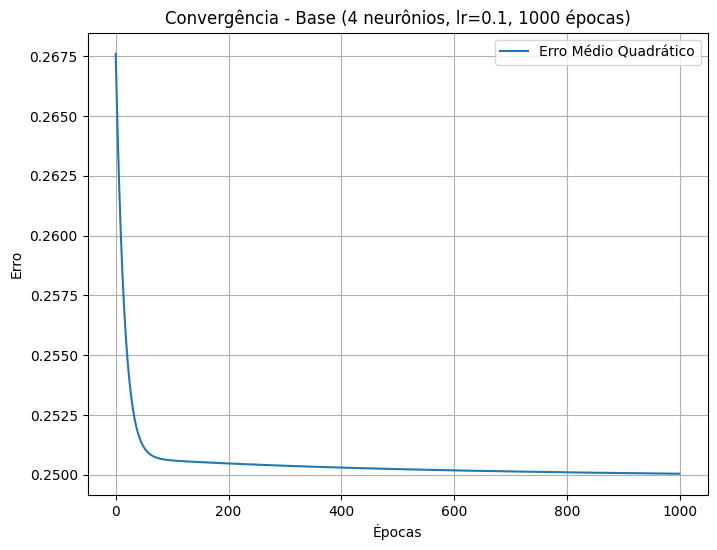

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Função de ativação sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivada da função sigmoid (usando a saída do sigmoid)
def sigmoid_derivative(x):
    return x * (1 - x)

# Classe da Rede Neural (MLP)
class NeuralNetwork:
    def __init__(self, input_size, hidden_sizes, output_size, learning_rate=0.1, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.weights = []
        # Inicializa os pesos com valores aleatórios entre -1 e 1
        for i in range(len(layer_sizes) - 1):
            weight_matrix = np.random.uniform(-1, 1, (layer_sizes[i], layer_sizes[i+1]))
            self.weights.append(weight_matrix)

    def feedforward(self, x):
        activations = [x]
        input_data = x
        for weight in self.weights:
            net_input = np.dot(input_data, weight)
            activation = sigmoid(net_input)
            activations.append(activation)
            input_data = activation
        return activations

    def backpropagation(self, activations, y_true):
        error = y_true - activations[-1]
        deltas = [error * sigmoid_derivative(activations[-1])]
        for i in reversed(range(len(self.weights)-1)):
            delta = deltas[-1].dot(self.weights[i+1].T) * sigmoid_derivative(activations[i+1])
            deltas.append(delta)
        deltas.reverse()
        for i in range(len(self.weights)):
            layer_input = np.atleast_2d(activations[i])
            delta = np.atleast_2d(deltas[i])
            self.weights[i] += self.learning_rate * layer_input.T.dot(delta)

    def train(self, X, y):
        history = []
        for epoch in range(self.epochs):
            for xi, yi in zip(X, y):
                activations = self.feedforward(xi)
                self.backpropagation(activations, yi)
            loss = np.mean(np.square(y - self.predict(X)))
            history.append(loss)
            if epoch % 1000 == 0:
                print(f"Época {epoch}, Erro: {loss:.4f}")
        return history

    def predict(self, X):
        y_pred = []
        for xi in X:
            activations = self.feedforward(xi)
            y_pred.append(activations[-1])
        return np.array(y_pred)

if __name__ == "__main__":
    # Dados do problema XOR
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([[0],
                  [1],
                  [1],
                  [0]])

    # Configuração base: 2 neurônios ocultos, lr 0.1, 1000 épocas
    nn = NeuralNetwork(input_size=2, hidden_sizes=[4], output_size=1, learning_rate=0.1, epochs=1000)
    history = nn.train(X, y)

    outputs = nn.predict(X)
    print("Saídas finais:")
    for xi, yi_pred in zip(X, outputs):
        print(f"Entrada: {xi}, Saída Prevista: {np.round(yi_pred)}")

    # Geração do gráfico de convergência
    plt.figure(figsize=(8, 6))
    plt.plot(history, label="Erro Médio Quadrático")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.title("Convergência - Base (4 neurônios, lr=0.1, 1000 épocas)")
    plt.legend()
    plt.grid(True)
    plt.savefig("grafico_base.png")
    plt.show()


Época 0, Erro: 0.2745
Época 1000, Erro: 0.2541
Época 2000, Erro: 0.2507
Época 3000, Erro: 0.2502
Época 4000, Erro: 0.2501
Saídas finais:
Entrada: [0 0], Saída Prevista: [1.]
Entrada: [0 1], Saída Prevista: [0.]
Entrada: [1 0], Saída Prevista: [1.]
Entrada: [1 1], Saída Prevista: [0.]


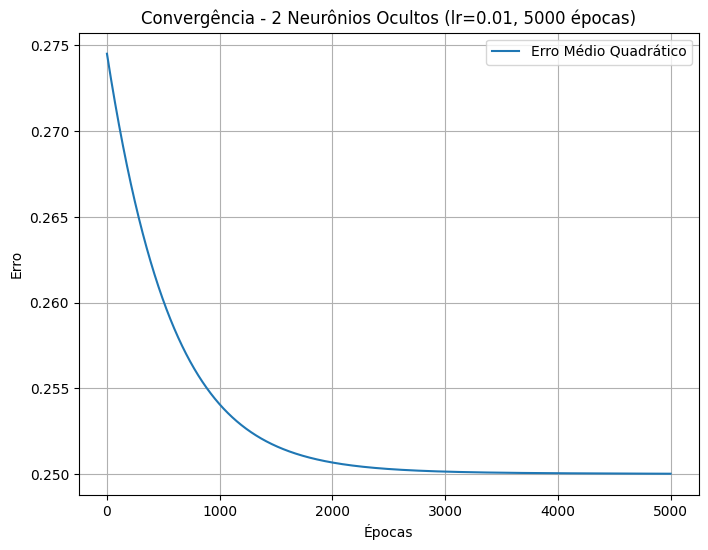

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, input_size, hidden_sizes, output_size, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.weights = []
        for i in range(len(layer_sizes) - 1):
            weight_matrix = np.random.uniform(-1, 1, (layer_sizes[i], layer_sizes[i+1]))
            self.weights.append(weight_matrix)

    def feedforward(self, x):
        activations = [x]
        input_data = x
        for weight in self.weights:
            net_input = np.dot(input_data, weight)
            activation = sigmoid(net_input)
            activations.append(activation)
            input_data = activation
        return activations

    def backpropagation(self, activations, y_true):
        error = y_true - activations[-1]
        deltas = [error * sigmoid_derivative(activations[-1])]
        for i in reversed(range(len(self.weights)-1)):
            delta = deltas[-1].dot(self.weights[i+1].T) * sigmoid_derivative(activations[i+1])
            deltas.append(delta)
        deltas.reverse()
        for i in range(len(self.weights)):
            layer_input = np.atleast_2d(activations[i])
            delta = np.atleast_2d(deltas[i])
            self.weights[i] += self.learning_rate * layer_input.T.dot(delta)

    def train(self, X, y):
        history = []
        for epoch in range(self.epochs):
            for xi, yi in zip(X, y):
                activations = self.feedforward(xi)
                self.backpropagation(activations, yi)
            loss = np.mean(np.square(y - self.predict(X)))
            history.append(loss)
            if epoch % 1000 == 0:
                print(f"Época {epoch}, Erro: {loss:.4f}")
        return history

    def predict(self, X):
        y_pred = []
        for xi in X:
            activations = self.feedforward(xi)
            y_pred.append(activations[-1])
        return np.array(y_pred)

if __name__ == "__main__":
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([[0],
                  [1],
                  [1],
                  [0]])

    # Configuração: 2 neurônios ocultos, taxa de aprendizagem 0.01, 1000 épocas
    nn = NeuralNetwork(input_size=2, hidden_sizes=[2], output_size=1, learning_rate=0.01, epochs=5000)
    history = nn.train(X, y)

    outputs = nn.predict(X)
    print("Saídas finais:")
    for xi, yi_pred in zip(X, outputs):
        print(f"Entrada: {xi}, Saída Prevista: {np.round(yi_pred)}")

    plt.figure(figsize=(8, 6))
    plt.plot(history, label="Erro Médio Quadrático")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.title("Convergência - 2 Neurônios Ocultos (lr=0.01, 5000 épocas)")
    plt.legend()
    plt.grid(True)
    plt.savefig("grafico_lr0.01.png")
    plt.show()


Época 0, Erro: 0.2606
Época 1000, Erro: 0.2490
Época 2000, Erro: 0.2484
Época 3000, Erro: 0.2478
Época 4000, Erro: 0.2470
Época 5000, Erro: 0.2459
Época 6000, Erro: 0.2445
Época 7000, Erro: 0.2427
Época 8000, Erro: 0.2405
Época 9000, Erro: 0.2378
Saídas finais:
Entrada: [0 0], Saída Prevista: [0.]
Entrada: [0 1], Saída Prevista: [1.]
Entrada: [1 0], Saída Prevista: [1.]
Entrada: [1 1], Saída Prevista: [1.]


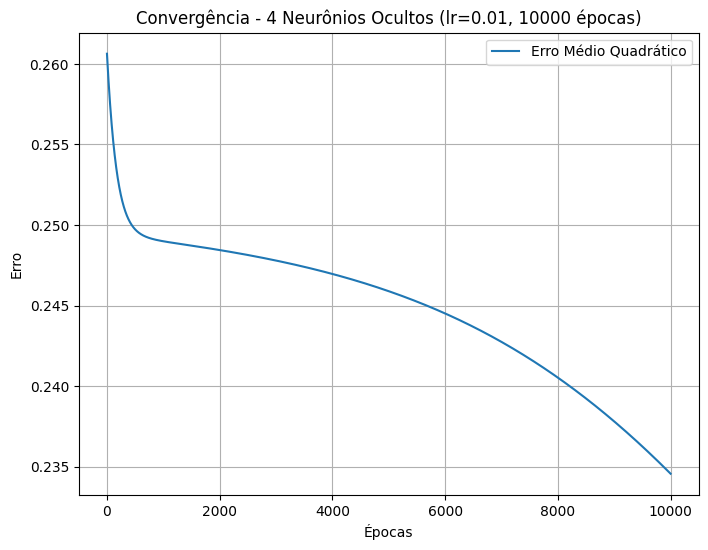

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, input_size, hidden_sizes, output_size, learning_rate=0.1, epochs=5000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.weights = []
        for i in range(len(layer_sizes) - 1):
            weight_matrix = np.random.uniform(-1, 1, (layer_sizes[i], layer_sizes[i+1]))
            self.weights.append(weight_matrix)

    def feedforward(self, x):
        activations = [x]
        input_data = x
        for weight in self.weights:
            net_input = np.dot(input_data, weight)
            activation = sigmoid(net_input)
            activations.append(activation)
            input_data = activation
        return activations

    def backpropagation(self, activations, y_true):
        error = y_true - activations[-1]
        deltas = [error * sigmoid_derivative(activations[-1])]
        for i in reversed(range(len(self.weights)-1)):
            delta = deltas[-1].dot(self.weights[i+1].T) * sigmoid_derivative(activations[i+1])
            deltas.append(delta)
        deltas.reverse()
        for i in range(len(self.weights)):
            layer_input = np.atleast_2d(activations[i])
            delta = np.atleast_2d(deltas[i])
            self.weights[i] += self.learning_rate * layer_input.T.dot(delta)

    def train(self, X, y):
        history = []
        for epoch in range(self.epochs):
            for xi, yi in zip(X, y):
                activations = self.feedforward(xi)
                self.backpropagation(activations, yi)
            loss = np.mean(np.square(y - self.predict(X)))
            history.append(loss)
            if epoch % 1000 == 0:
                print(f"Época {epoch}, Erro: {loss:.4f}")
        return history

    def predict(self, X):
        y_pred = []
        for xi in X:
            activations = self.feedforward(xi)
            y_pred.append(activations[-1])
        return np.array(y_pred)

if __name__ == "__main__":
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([[0],
                  [1],
                  [1],
                  [0]])

    # Configuração: 2 neurônios ocultos, lr=0.1, 5000 épocas
    nn = NeuralNetwork(input_size=2, hidden_sizes=[4], output_size=1, learning_rate=0.01, epochs=10000)
    history = nn.train(X, y)

    outputs = nn.predict(X)
    print("Saídas finais:")
    for xi, yi_pred in zip(X, outputs):
        print(f"Entrada: {xi}, Saída Prevista: {np.round(yi_pred)}")

    plt.figure(figsize=(8, 6))
    plt.plot(history, label="Erro Médio Quadrático")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.title("Convergência - 4 Neurônios Ocultos (lr=0.01, 10000 épocas)")
    plt.legend()
    plt.grid(True)
    plt.savefig("grafico_5000epochs.png")
    plt.show()


Época 0, Erro: 0.2555
Época 1000, Erro: 0.0889
Época 2000, Erro: 0.0048
Época 3000, Erro: 0.0021
Época 4000, Erro: 0.0013
Saídas finais:
Entrada: [0 0], Saída Prevista: [0.]
Entrada: [0 1], Saída Prevista: [1.]
Entrada: [1 0], Saída Prevista: [1.]
Entrada: [1 1], Saída Prevista: [0.]


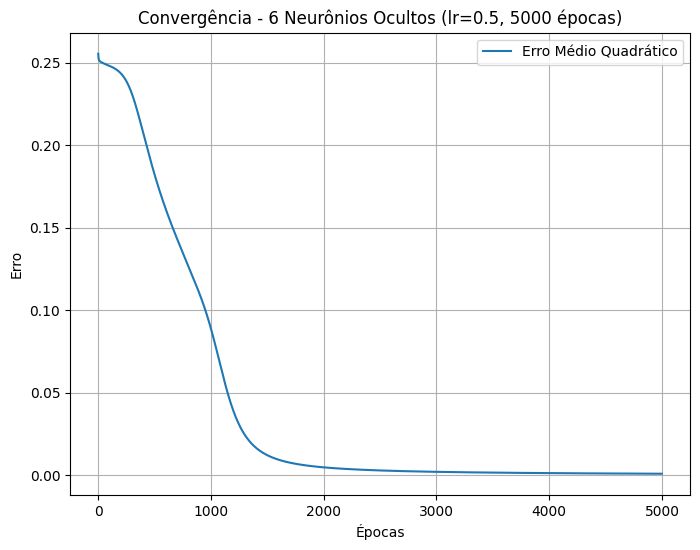

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, input_size, hidden_sizes, output_size, learning_rate=0.1, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.weights = []
        for i in range(len(layer_sizes) - 1):
            weight_matrix = np.random.uniform(-1, 1, (layer_sizes[i], layer_sizes[i+1]))
            self.weights.append(weight_matrix)

    def feedforward(self, x):
        activations = [x]
        input_data = x
        for weight in self.weights:
            net_input = np.dot(input_data, weight)
            activation = sigmoid(net_input)
            activations.append(activation)
            input_data = activation
        return activations

    def backpropagation(self, activations, y_true):
        error = y_true - activations[-1]
        deltas = [error * sigmoid_derivative(activations[-1])]
        for i in reversed(range(len(self.weights)-1)):
            delta = deltas[-1].dot(self.weights[i+1].T) * sigmoid_derivative(activations[i+1])
            deltas.append(delta)
        deltas.reverse()
        for i in range(len(self.weights)):
            layer_input = np.atleast_2d(activations[i])
            delta = np.atleast_2d(deltas[i])
            self.weights[i] += self.learning_rate * layer_input.T.dot(delta)

    def train(self, X, y):
        history = []
        for epoch in range(self.epochs):
            for xi, yi in zip(X, y):
                activations = self.feedforward(xi)
                self.backpropagation(activations, yi)
            loss = np.mean(np.square(y - self.predict(X)))
            history.append(loss)
            if epoch % 1000 == 0:
                print(f"Época {epoch}, Erro: {loss:.4f}")
        return history

    def predict(self, X):
        y_pred = []
        for xi in X:
            activations = self.feedforward(xi)
            y_pred.append(activations[-1])
        return np.array(y_pred)

if __name__ == "__main__":
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([[0],
                  [1],
                  [1],
                  [0]])

    # Configuração: 6 neurônios na camada oculta, lr=0.1, 1000 épocas
    nn = NeuralNetwork(input_size=2, hidden_sizes=[6], output_size=1, learning_rate=0.5, epochs=5000)
    history = nn.train(X, y)

    outputs = nn.predict(X)
    print("Saídas finais:")
    for xi, yi_pred in zip(X, outputs):
        print(f"Entrada: {xi}, Saída Prevista: {np.round(yi_pred)}")

    plt.figure(figsize=(8, 6))
    plt.plot(history, label="Erro Médio Quadrático")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.title("Convergência - 6 Neurônios Ocultos (lr=0.5, 5000 épocas)")
    plt.legend()
    plt.grid(True)
    plt.savefig("grafico_6neurons.png")
    plt.show()


Época 0, Erro: 0.3005
Época 1000, Erro: 0.2481
Época 2000, Erro: 0.2331
Época 3000, Erro: 0.1598
Época 4000, Erro: 0.0680
Época 5000, Erro: 0.0308
Época 6000, Erro: 0.0183
Época 7000, Erro: 0.0127
Época 8000, Erro: 0.0095
Época 9000, Erro: 0.0076
Saídas finais:
Entrada: [0 0], Saída Prevista: [0.]
Entrada: [0 1], Saída Prevista: [1.]
Entrada: [1 0], Saída Prevista: [1.]
Entrada: [1 1], Saída Prevista: [0.]


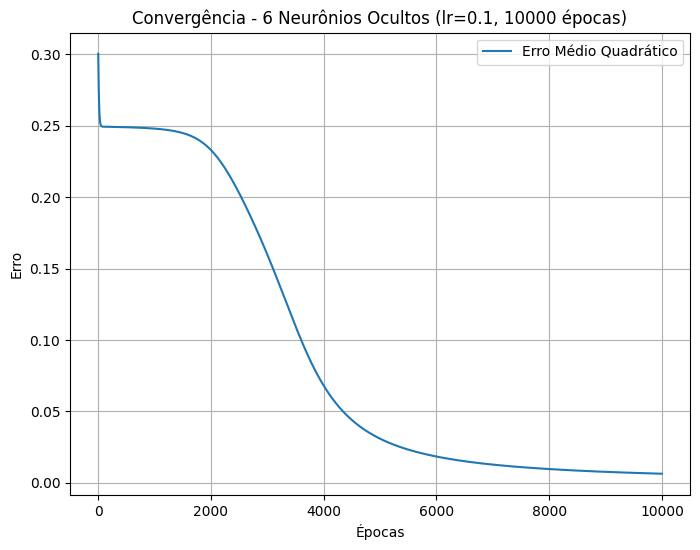

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, input_size, hidden_sizes, output_size, learning_rate=0.1, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.weights = []
        for i in range(len(layer_sizes) - 1):
            weight_matrix = np.random.uniform(-1, 1, (layer_sizes[i], layer_sizes[i+1]))
            self.weights.append(weight_matrix)

    def feedforward(self, x):
        activations = [x]
        input_data = x
        for weight in self.weights:
            net_input = np.dot(input_data, weight)
            activation = sigmoid(net_input)
            activations.append(activation)
            input_data = activation
        return activations

    def backpropagation(self, activations, y_true):
        error = y_true - activations[-1]
        deltas = [error * sigmoid_derivative(activations[-1])]
        for i in reversed(range(len(self.weights)-1)):
            delta = deltas[-1].dot(self.weights[i+1].T) * sigmoid_derivative(activations[i+1])
            deltas.append(delta)
        deltas.reverse()
        for i in range(len(self.weights)):
            layer_input = np.atleast_2d(activations[i])
            delta = np.atleast_2d(deltas[i])
            self.weights[i] += self.learning_rate * layer_input.T.dot(delta)

    def train(self, X, y):
        history = []
        for epoch in range(self.epochs):
            for xi, yi in zip(X, y):
                activations = self.feedforward(xi)
                self.backpropagation(activations, yi)
            loss = np.mean(np.square(y - self.predict(X)))
            history.append(loss)
            if epoch % 1000 == 0:
                print(f"Época {epoch}, Erro: {loss:.4f}")
        return history

    def predict(self, X):
        y_pred = []
        for xi in X:
            activations = self.feedforward(xi)
            y_pred.append(activations[-1])
        return np.array(y_pred)

if __name__ == "__main__":
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([[0],
                  [1],
                  [1],
                  [0]])

    # Configuração: 4 neurônios na camada oculta, lr=0.1, 1000 épocas
    nn = NeuralNetwork(input_size=2, hidden_sizes=[6], output_size=1, learning_rate=0.1, epochs=10000)
    history = nn.train(X, y)

    outputs = nn.predict(X)
    print("Saídas finais:")
    for xi, yi_pred in zip(X, outputs):
        print(f"Entrada: {xi}, Saída Prevista: {np.round(yi_pred)}")

    plt.figure(figsize=(8, 6))
    plt.plot(history, label="Erro Médio Quadrático")
    plt.xlabel("Épocas")
    plt.ylabel("Erro")
    plt.title("Convergência - 6 Neurônios Ocultos (lr=0.1, 10000 épocas)")
    plt.legend()
    plt.grid(True)
    plt.savefig("grafico_4neurons.png")
    plt.show()
